In [ ]:
!pip install "iqm-client[qiskit]==34.0.3" "matplotlib==3.11.0" "numpy==2.4.6" "pylatexenc==2.10" "qiskit==2.1.2" "scikit-learn==1.9.0" "squlearn==0.11.2"

There is a great library for QML that can actually run on various backends. [sQUlearn](https://squlearn.github.io/index.html) is build by colleagues at Fraunhofer and aims to provide a significant abstraction layer so that it becomes easy to move from emulation to hardware.

![squlearn](https://raw.githubusercontent.com/sQUlearn/squlearn/main/docs/_static/schematic.png)

We will benefit from that work and follow the examples at https://squlearn.github.io/examples/example_kernel_digit_classification.html and see if we can make a quantum computer classify hand written digits.

![mnist](https://squlearn.github.io/_images/pipeline.png)

## Imports and Definitions

In [1]:
import matplotlib.pylab as plt
from matplotlib.lines import Line2D
import numpy as np

from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

from squlearn import Executor
from squlearn.encoding_circuit import ChebyshevPQC
from squlearn.kernel.qsvc import QSVC
from squlearn.kernel.lowlevel_kernel import ProjectedQuantumKernel

The definitions of the helper functions are hidden on the website for sake of readability. If you want to replicate this code, please see the definitions of the helper functions at [the original notebook](https://github.com/sQUlearn/squlearn/blob/main/examples/tutorials/kernel_digit_classification.ipynb)

In [3]:
def plot_data_in_feature_space(X, y, highlight_rows):
    X_m = np.ma.array(X, mask=False)
    X_m.mask[highlight_rows] = True

    y_m = np.ma.array(y, mask=False)
    y_m.mask[highlight_rows] = True

    fig, ax = plt.subplots(figsize=(12, 8))
    s1 = ax.scatter(X_m[:, 0], X_m[:, 1], c=y_m, cmap=plt.cm.tab10, marker="o", s=10)
    s2 = ax.scatter(
        X[highlight_rows, 0],
        X[highlight_rows, 1],
        c=y[highlight_rows],
        cmap=plt.cm.tab10,
        marker="X",
        s=80,
        edgecolors="k",
        vmin=0,
        vmax=9,
    )
    ax.legend(
        [
            Line2D(
                [0],
                [0],
                color="w",
                marker="X",
                markerfacecolor="w",
                markeredgecolor="k",
                markersize=10,
            ),
            Line2D(
                [0],
                [0],
                color="w",
                marker="o",
                markerfacecolor="w",
                markeredgecolor="k",
                markersize=6,
            ),
        ],
        ["Samples", "Dataset"],
        loc="lower right",
    )
    cbar = fig.colorbar(s2, ticks=(0.5 + np.arange(10)) * 10 / 11)
    cbar.ax.set_yticklabels(np.arange(10, dtype=int))
    cbar.ax.tick_params(size=0, labelsize="large")


def plot_dataset(X, y, rows=5):
    indices = np.stack(
        [
            np.random.choice(np.argwhere(y == i).ravel(), size=rows, replace=False)
            for i in range(10)
        ]
    )
    fig, axs = plt.subplots(rows, 11)
    for i in range(rows):
        axs[i][0].axis("off")
        axs[i][0].set_aspect("equal")
        for j in range(10):
            axs[i][j + 1].imshow(X[indices[j, i], :].reshape(8, 8), cmap="Greys")
            axs[i][j + 1].axis("off")
            axs[i][j + 1].set_aspect("equal")

    axs[0][0].set_title("label:")

    for j in range(10):
        axs[0][j + 1].set_title(f"{j}")

    fig.subplots_adjust(wspace=0, hspace=0)


def plot_numbers(X, y, title: str = None):
    fig, axs = plt.subplots(
        1,
        X.shape[0] + int(title != None),
        figsize=(X.shape[0] + int(title != None) + 1, 2),
    )
    fig.suptitle("Samples")
    if title:
        axs[0].axis("off")
        axs[0].set_title(title)
        axs[0].set_aspect("equal")
    if not isinstance(X, np.ndarray):
        X = X.to_numpy()
    if not isinstance(y, np.ndarray):
        y = y["class"]
    for i, (data, label) in enumerate(zip(X, y)):
        axs[i + int(title != None)].imshow(data.reshape(8, 8), cmap="Greys")
        axs[i + int(title != None)].axis("off")
        axs[i + int(title != None)].set_title(label)


def plot_results(
    clf, X_train, y_train, X_test, y_test, X_highlight, y_highlight, X_range, resolution
):
    xx, yy = np.meshgrid(
        np.linspace(X_range[0][0], X_range[0][1], resolution),
        np.linspace(X_range[0][0], X_range[0][1], resolution),
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(12, 8))
    pc = ax.pcolor(xx, yy, Z.astype(int), cmap=plt.cm.tab10, alpha=0.5)

    s1 = ax.scatter(
        X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.tab10, s=20, edgecolors="k"
    )
    s2 = ax.scatter(
        X_test[:, 0],
        X_test[:, 1],
        c=y_test,
        cmap=plt.cm.tab10,
        marker="v",
        s=30,
        edgecolors="k",
    )
    s3 = ax.scatter(
        X_highlight[:, 0],
        X_highlight[:, 1],
        c=y_highlight,
        cmap=plt.cm.tab10,
        marker="X",
        s=80,
        edgecolors="w",
        linewidth=2,
        vmin=0,
        vmax=9,
    )

    ax.legend(
        [
            Line2D(
                [0],
                [0],
                color="w",
                marker="o",
                markerfacecolor="w",
                markeredgecolor="k",
                lw=0,
            ),
            Line2D(
                [0],
                [0],
                color="w",
                marker="v",
                markerfacecolor="w",
                markeredgecolor="k",
                lw=0,
            ),
            Line2D(
                [0],
                [0],
                color="w",
                marker="X",
                markerfacecolor="w",
                markeredgecolor="k",
                markersize=10,
                lw=0,
            ),
        ],
        ["Training", "Test", "Samples"],
        loc="lower right",
    )

    cbar = fig.colorbar(s2, ticks=(0.5 + np.arange(10)) * 10 / 11)
    cbar.ax.set_yticklabels(np.arange(10, dtype=int))
    cbar.ax.tick_params(size=0, labelsize="large")

## The Data
Classification of handwritten digits is a widely known task in machine learning. We utilize the data set included in scikit-learn. The data set is comprised of pictures of the size $8 \times 8$ pixels that contain one single digit each as well as their according label, the numeric digit, depicted. We start by loading the data set and display the data.

In [4]:
X, y = load_digits(return_X_y=True)

The input data is stored in row vectors of dimension $64 \left(= 8 \times 8\right)$, one for each pixel, and the class label is a numeric value between $0$ and $9$. Let us continue to visualize some samples from the data set.

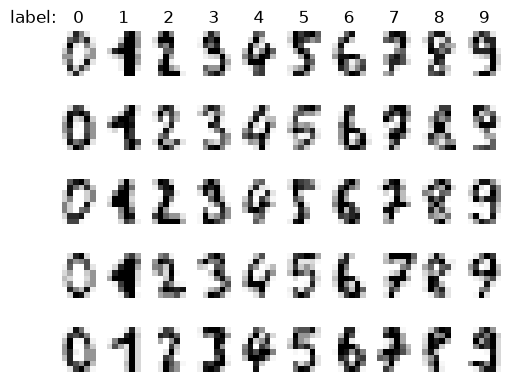

In [5]:
plot_dataset(X, y, rows=5)
plt.show()

## Preprocessing
To make the data readable by the machine learning model, we need to perform a couple of preprocessing step, starting with dimensionality reduction.

### Dimensionality Reduction
State of the art quantum computers can perform computations on a limited set of qubits. Also simulating them on classical hardware is only possible for a few such qubits. Handling our $64$ input features (one for every pixel) would result in either a very wide (not possible yet) or very deep (very noisy) quantum circuit for our encoding circuit. Therefore we perform dimensionality reduction in form of T-SNE. This leaves us with two features for every input image.

In [6]:
X_tsne = TSNE(n_components=2, learning_rate="auto", init="random", perplexity=40).fit_transform(X)

We can now plot the data in the feature space.

*Hint: Rerun the cell a couple of times to view different samples and their respective position in feature space.*

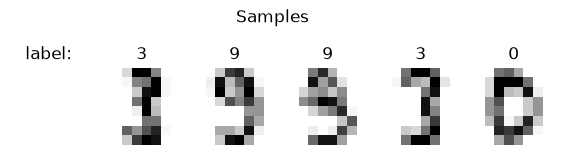

In [7]:
rows = np.random.choice(np.arange(1000, X.shape[0]), 5, replace=False)
plot_numbers(X[rows, :], y[rows], title="label:")
plt.show()

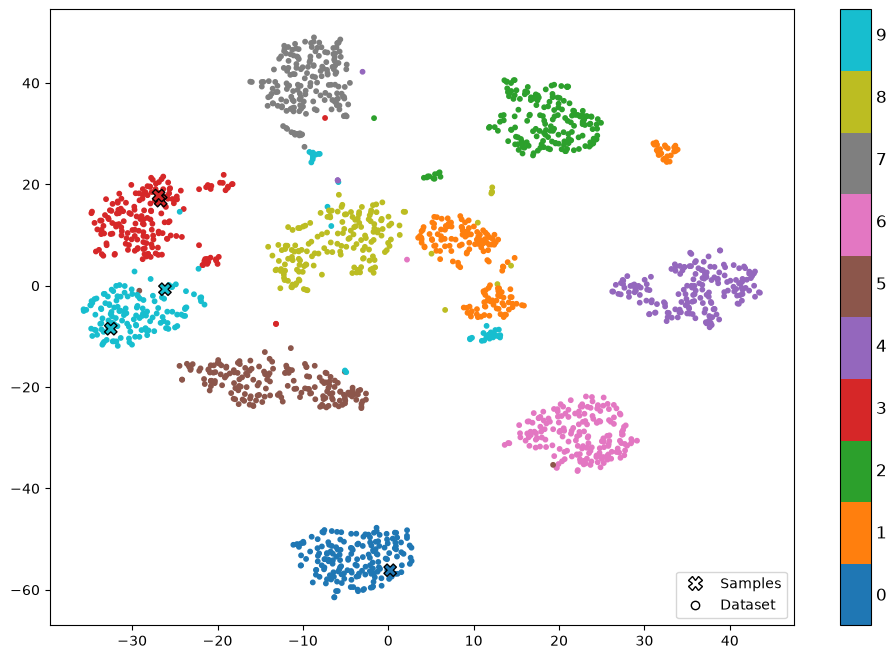

In [8]:
plot_data_in_feature_space(X_tsne, y, highlight_rows=rows)
plt.show()

We can clearly see the different clusters of numbers in the new feature space. We also see the location of our samples marked by 🞭 with their true label.

### Split Data sets

Lastly we select $n$ samples and split the data set into one for training and one for testing.

In [9]:
n_samples = 1000

X_train, X_test, y_train, y_test = train_test_split(
    X_tsne[:n_samples, :],
    y[:n_samples],
    test_size=0.33,
    random_state=42,
)

### Min Max Scaling
Next we continue to scale the data to be in the interval $\left[-0.9, 0.9\right]$ for both dimensions. This improves performance of the machine learning model by not overly considering one of the features.

In [10]:
scaler = MinMaxScaler((-0.9, 0.9))
X_train_1 = scaler.fit_transform(X_train)
X_test_1 = scaler.transform(X_test)

## Classification
We are now set to continue learning a model to classify the numbers.

### Quantum Kernel Methods
Kernel methods are a set of powerful techniques used in machine learning for solving various problems, such as classification, regression, and clustering.

![enc](https://github.com/sQUlearn/squlearn/blob/main/examples/tutorials/images/encoding_circuit.png?raw=true)

The core idea behind kernel methods is to transform the input data $x$ into a high-dimensional feature space, where it becomes easier to separate or classify the data. The figure above shows an example for such a transformation $\phi\left(x\right)$. It's not possible to separate the data on the left with a line but we can separate the data on the right with a hyperplane. We continue to calculate the similarity between two data points $x$ and $y$ in the high-dimensional space by evaluating the scalar product $\langle \phi\left(x\right), \phi\left(y\right) \rangle$. The classical kernel trick allows us to directly compute the similarity between the data points without explicitly calculating the encoding circuits.

### Quantum Kernels
Quantum kernels leverage parameterized quantum circuits (PQC) to map an input $x$ to a quantum state $\ket{\phi\left(x\right)}$ in a potentially high dimensional quantum Hilbert space. In this case, the encoding circuit (cf. Fig. 2) is the data encoding map. We obtain a quantum kernel by measuring the similarity between the wave functions created by encoding two different values $x$ and $y$
$$k\left(x, y\right) = \left\vert\left\langle\phi(x)\vert \phi(y)\right\rangle\right\vert^2\text{.}$$

Calculating quantum kernels by encoding the features separately has several drawbacks. For example, each element of the kernel matrix has to be calculated separately, such that the overall calculation of the kernel matrix scales quadratically with the size of the data set. In this demonstrator, we projected quantum kernels instead. They have some intriguing properties.

### Projected Quantum Kernel
With large effective dimensions (the dimension of the feature space), quantum kernels will see all data far from each other and thus have bad learning performance. Projected quantum kernels alleviate this problem by projecting the feature back to a classical space and computing the kernel there. This also comes with the advantage of needing to encode each input into quantum Hilbert space only once which leads to a linear scaling with the number of data points.

![proj](https://github.com/sQUlearn/squlearn/blob/main/examples/tutorials/images/projected_quantum_kernel.png?raw=true)

<font size="2">Fig. 3: Visualization of a projected quantum kernel.\
Reprinted from Huang, HY., Broughton, M., Mohseni, M. *et al.* Power of data in quantum machine learning. *Nat Commun* **12**, 2631 (2021). [https://doi.org/10.1038/s41467-021-22539-9](https://doi.org/10.1038/s41467-021-22539-9), licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).</font>
</center>

In this notebook, we encode the classical data into a quantum computer using a  PQC with four qubits and three data-encoding layers. Each layer applies rotations $\mathrm{R}_\mathrm{X}$, using the product of a trainable parameter with the $\arccos$ of the input as the rotation angle and is followed by a circular entanglement layer using parameterized controlled $\mathrm{R}_\mathrm{Z}$ gates. The layers are enclosed in between two layers of parameterized $\mathrm{R}_\mathrm{Y}$ rotations. We will use a parameter vector $x$ for the input data and a parameter vector $p$ for the trainable parameters.

Let's plot the resulting quantum circuit.

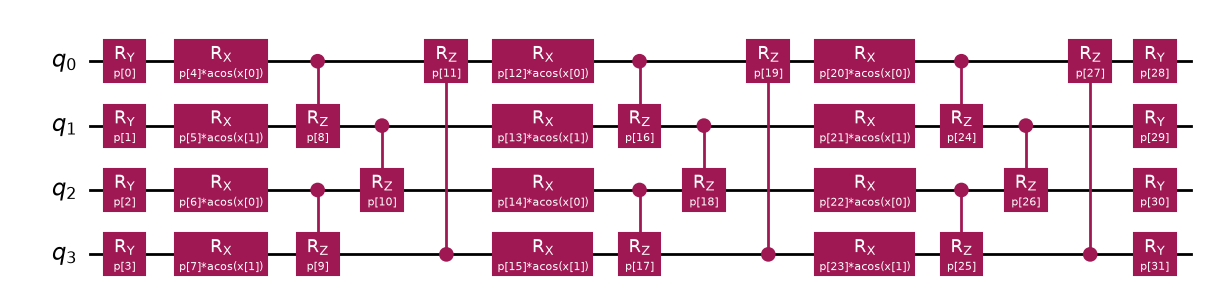

In [11]:
encoding_circuit = ChebyshevPQC(num_qubits=4, num_layers=3)
encoding_circuit.draw(output="mpl", num_features=2)

Note that since we only have a two-dimensional input $x$ but twelve encoding quantum gates, we will repeat the data for the gates in ascending layer and qubit order. The resulting model is thus called a data re-uploading model. Each gate has their own trainable parameter, leaving us with $32$ trainable parameters.

Let's use the PQC to create a kernel matrix. We will measure in $\mathrm{X}$, $\mathrm{Y}$ and $\mathrm{Z}$ direction on each qubit. This maps the embedded data back to a classical feature space of dimension $12$. Furthermore, the projected quantum kernel will use a Gaussian outer kernel, i.e. it will compute each matrix element as
$$ K_{ij} = \exp\left(-\gamma\left\lvert\mathrm{PQC}\left(\theta,x_i\right)-\mathrm{PQC}\left(\theta,x_j\right)\right\rvert_2^2\right)$$
where $\left\lvert\cdot\right\rvert_2$ corresponds to the $L_2$-norm for vectors. $\gamma$ is a parameter which we will fix to $0.5$. Note again, that we only need to compute each encoding circuit $x_i\mapsto\mathrm{PQC}\left(\theta,x_i\right)$ once.

In [12]:
kernel = ProjectedQuantumKernel(
    encoding_circuit=encoding_circuit,
    executor=Executor(),
    measurement="XYZ",
    outer_kernel="gaussian",
    initial_parameters=np.random.rand(encoding_circuit.num_parameters),
    gamma=0.5,
)

INFO:executor:Set shots to None
INFO:executor:Executor initialized with pennylane
INFO:executor:Executor intial shots: None


### Support Vector Machine
We are now ready to train a Support Vector Machine (SVM) with our quantum kernel.

A Support Vector Machine (SVM) is a machine learning algorithm used for classification or regression tasks. It works by finding a hyperplane that separates data points into different categories. The hyperplane is chosen so that it maximizes the distance between the closest data points from each category. These closest points are called support vectors, and they help define the decision boundary. Once the decision boundary is established, new data points can be classified based on which side of the boundary they fall on.

Let's now fit the SVM to our training data.

In [13]:
qsvc = QSVC(quantum_kernel=kernel)
qsvc.fit(X_train_1, y_train)

INFO:executor:Execution of pennylane circuit function
INFO:executor:Execution of pennylane circuit successful
/usr/local/lib/python3.12/dist-packages/sklearn/externals/_numpydoc/docscrape.py:420: UserWarning: Unknown section Methods:
  self[section] = content


,quantum_kernel,<squlearn.ker...x7a814e123ef0>
,C,1.0
,break_ties,False
,cache_size,200
,class_weight,None
,decision_function_shape,'ovr'
,max_iter,-1
,probability,'deprecated'
,random_state,None
,shrinking,True
,tol,0.001


We check its performance on the training and test data.

In [14]:
predictions = qsvc.predict(X_train_1)
print(f'Train accuracy score {accuracy_score(y_train, predictions)}')

Train accuracy score 0.9552238805970149


In [15]:
predictions_1 = qsvc.predict(X_test_1)
print(f'Test accuracy score {accuracy_score(y_test, predictions_1)}')

INFO:executor:Execution of pennylane circuit function
INFO:executor:Execution of pennylane circuit successful


Test accuracy score 0.9666666666666667


The accuracy score describes the share of correctly classified data points. In multiclass classification it is calculated as

$$
\text{Accuracy} = \frac{\text{correct classifications}}{\text{total classifications}}\text{.}
$$

We can go back to the previous plot we created and add more information to it. Specifically, we will highlight which data points were used for training and testing, and we will also show the true labels for each data point. To help us understand how the SVM makes its decisions, we will add a line on the plot called the decision boundary. Additionally, the colors of the background in the plot will indicate the region where the SVM assigns a specific label to each data point.

INFO:executor:Execution of pennylane circuit function
INFO:executor:Execution of pennylane circuit successful


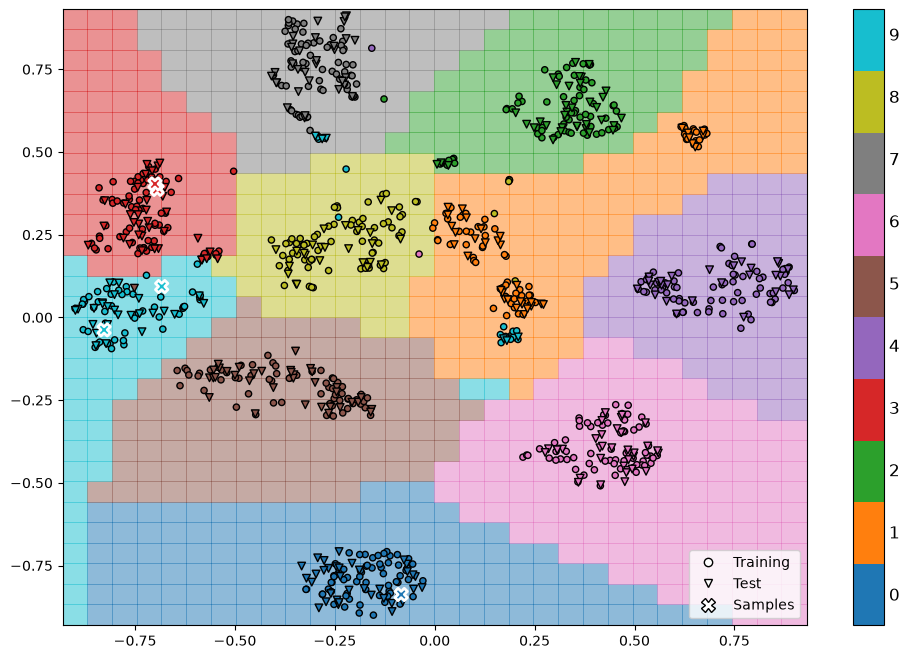

In [16]:
plot_results(clf=qsvc, X_train=X_train_1, y_train=y_train, X_test=X_test_1, y_test=y_test, X_highlight=scaler.transform(X_tsne[rows]), y_highlight=y[rows], X_range=[(-0.9, 0.9), (-0.9, 0.9)], resolution=30)
plt.show()

Finally let's see how our model predicts the data samples we chose in the beginning.

INFO:executor:Execution of pennylane circuit function
INFO:executor:Execution of pennylane circuit successful


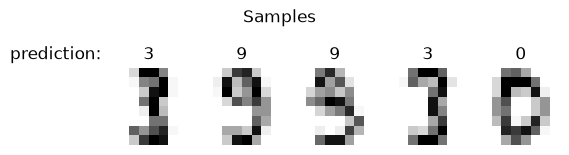

In [17]:
y_pred = qsvc.predict(scaler.transform(X_tsne[rows, :]))

plot_numbers(X[rows, :], y_pred, title="prediction:")
plt.show()

## On hardware

Now, sQUlearn allows for a variety of Executors but in order what goes under the hood and have a more fine-grained access we will use Qiskit Machine Learning [example](https://qiskit-community.github.io/qiskit-machine-learning/tutorials/03_quantum_kernel.html) computing the train and test matrices for the QSVC model.

```py
adhoc_matrix_train = adhoc_kernel.evaluate(x_vec=train_features)
adhoc_matrix_test = adhoc_kernel.evaluate(x_vec=test_features, y_vec=train_features)
```

These two matrices are actually the computation of the kernel $k(x_i,x_j)$ that are used to select the support vectors and then test against those.

![mats](https://qiskit-community.github.io/qiskit-machine-learning/_images/tutorials_03_quantum_kernel_17_0.png)

In [18]:
print(f"Training matrix requires {(X_train.shape[0]*(X_train.shape[0]+1))/2} circuit executions")
print(f"Test requires {X_train.shape[0]*X_test.shape[0]}")

Training matrix requires 224785.0 circuit executions
Test requires 221100


We might want to try again with the Iris dataset just not to run out of credits. In fact, we might need to use just a set of samples from it.

In [19]:
from sklearn import datasets

# import some data to play with
iris = datasets.load_iris()
iris_X = iris.data[50:150, :2]  # we only take the first two features.
iris_Y = iris.target[50:150] # and first 100 samples

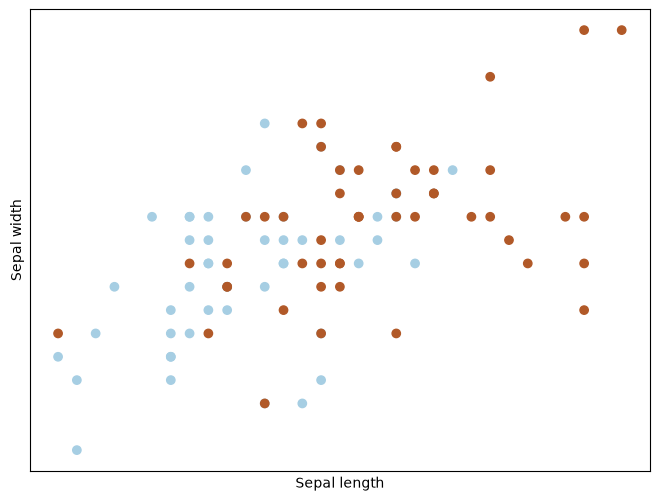

In [20]:
plt.figure(2, figsize=(8, 6))
plt.clf()

# Plot the training points
plt.scatter(iris_X[:, 0], iris_X[:, 1], c=iris_Y, cmap=plt.cm.Paired)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')

plt.xticks(())
plt.yticks(())

plt.show()

Let's just select a couple of examples and see what we get.

In [21]:
_data_samples = 2

X_train_hard, X_test_hard, y_train_hard, y_test_hard = train_test_split(
    np.concat([iris_X[:_data_samples, :], iris_X[-_data_samples:, :]]),
    np.concat([iris_Y[:_data_samples], iris_Y[-_data_samples:]]),
    test_size=0.33,
    random_state=42, # Change the seed to produce different results
)

# Scale
_scaler = MinMaxScaler((-0.9, 0.9))
X_train_scl = _scaler.fit_transform(X_train_hard)
X_test_scl = _scaler.transform(X_test_hard)

In [22]:
from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

fmap = zz_feature_map(feature_dimension=2, reps=2, entanglement="linear")

sampler = Sampler()
fidelity = ComputeUncompute(sampler=sampler)

iris_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=fmap)

In [23]:
q_svc = SVC(kernel=iris_kernel.evaluate)
q_svc.fit(X_train_scl, y_train_hard)
iris_score = q_svc.score(X_test_scl, y_test_hard)

print(f"Callable kernel classification test score: {iris_score}")

Callable kernel classification test score: 0.5


In [24]:
print(f"Training matrix requires {(X_train_scl.shape[0]*(X_train_scl.shape[0]+1))/2} circuit executions")
print(f"Test requires {X_train_scl.shape[0]*X_test_scl.shape[0]}")

Training matrix requires 3.0 circuit executions
Test requires 4


Now we need to submit it to IQM...

In [25]:
import os
from getpass import getpass

os.environ["IQM_TOKEN"] = getpass("Here goes your IQM API token:")

Here goes your IQM API token:··········


In [26]:
from iqm.qiskit_iqm import IQMProvider

IQM_URL = "https://resonance.meetiqm.com/"
QUANTUM_COMPUTER = "emerald"

provider = IQMProvider(IQM_URL, quantum_computer=QUANTUM_COMPUTER)
backend = provider.get_backend()
print(f"Connected to : {backend.name}")

Connected to : IQMBackend


Sometimes we will find devices are not easy to invoke from some open source libraries, but sQUlearn allows us to expand it's _Executor_ class to do so.

In [27]:
from iqm.qiskit_iqm import transpile_to_IQM

class IQMExecutor(Executor):
    """
    Executor for IQM hardware with fixed transpilation method.
    This executor overrides both sampler_run_v2 and estimator_run_v2 methods to ensure
    circuits are properly transpiled for IQM hardware before execution.

    The executor provides seamless integration with IQM quantum computers while
    maintaining all squlearn features like caching, session management, and
    automatic job retries.
    """

    def __init__(
        self,
        backend,
        shots=1000,
        caching=True,
        cache_dir="./cache",
        **kwargs,
    ):
        # Store backend and shots before calling super()
        self.iqm_backend = backend
        self._shots = shots

        # Call parent constructor
        super().__init__(
            execution=backend,
            shots=shots,
            caching=caching,
            cache_dir=cache_dir,
            **kwargs,
        )

        # Ensure backend is accessible via standard attribute
        self._backend = backend

    def sampler_run_v2(self, pubs, **kwargs):
        """
        Override the sampler_run_v2 method to pre-transpile circuits using IQM transpiler.
        This ensures all circuits are properly transpiled for IQM hardware before execution.

        Args:
            pubs: Iterable of pub-like objects (circuits to execute)
            **kwargs: Additional arguments passed to the sampler

        Returns:
            A qiskit job containing the results of the run
        """
        from iqm.qiskit_iqm import transpile_to_IQM

        # Try to import SamplerPub for Qiskit 2.1.2+, but handle older versions gracefully
        try:
            from qiskit.primitives import SamplerPub
            has_sampler_pub = True
        except ImportError:
            has_sampler_pub = False
            SamplerPub = None

        # Convert pubs to list to process them
        pubs_list = list(pubs)
        transpiled_pubs = []

        for pub in pubs_list:
            # Handle SamplerPub objects if available (Qiskit 2.1.2+)
            if has_sampler_pub and isinstance(pub, SamplerPub):
                # Extract the circuit from the SamplerPub
                circuit = pub.circuit
                parameter_values = pub.parameter_values
                shots = pub.shots if pub.shots is not None else self._shots

                try:
                    # Transpile circuit for IQM hardware
                    transpiled_circuit = transpile_to_IQM(circuit, backend=self.iqm_backend)

                    # Create a new SamplerPub with the transpiled circuit
                    transpiled_pub = SamplerPub(
                        circuit=transpiled_circuit,
                        parameter_values=parameter_values,
                        shots=shots
                    )
                    transpiled_pubs.append(transpiled_pub)

                except Exception as e:
                    print(f"Warning: Failed to transpile circuit: {e}")
                    print("Falling back to original circuit")
                    # Use the original pub if transpilation fails
                    transpiled_pubs.append(pub)
            else:
                # Handle tuple formats (works for all Qiskit versions)
                # Examples from Qiskit 2.1.2 docs:
                # (circuit,)
                # (circuit, parameter_values)
                # (circuit, parameter_values, shots)
                if isinstance(pub, tuple) and len(pub) > 0:
                    circuit = pub[0] if len(pub) > 0 else None
                    if circuit is not None:
                        try:
                            # Transpile circuit for IQM hardware
                            transpiled_circuit = transpile_to_IQM(circuit, backend=self.iqm_backend)

                            # Reconstruct the pub tuple with transpiled circuit
                            if len(pub) == 1:
                                transpiled_pubs.append((transpiled_circuit,))
                            elif len(pub) == 2:
                                transpiled_pubs.append((transpiled_circuit, pub[1]))
                            elif len(pub) == 3:
                                transpiled_pubs.append((transpiled_circuit, pub[1], pub[2]))
                            else:
                                transpiled_pubs.append(pub)

                        except Exception as e:
                            print(f"Warning: Failed to transpile circuit: {e}")
                            print("Falling back to original circuit")
                            transpiled_pubs.append(pub)
                    else:
                        transpiled_pubs.append(pub)
                else:
                    # Handle other formats (e.g., plain QuantumCircuit)
                    transpiled_pubs.append(pub)

        # Call the parent class method with transpiled circuits
        return super().sampler_run_v2(transpiled_pubs, **kwargs)

    def estimator_run_v2(self, pubs, precision=None, **kwargs):
        """
        Override the estimator_run_v2 method to pre-transpile circuits using IQM transpiler.
        This ensures all circuits are properly transpiled for IQM hardware before execution.

        Args:
            pubs: Iterable of pub-like objects (circuits and observables to execute)
            precision: Target precision for expectation value estimates
            **kwargs: Additional arguments passed to the estimator

        Returns:
            A qiskit job containing the results of the run
        """
        from iqm.qiskit_iqm import transpile_to_IQM

        # Try to import EstimatorPub for Qiskit 2.1.2+, but handle older versions gracefully
        try:
            from qiskit.primitives import EstimatorPub
            has_estimator_pub = True
        except ImportError:
            has_estimator_pub = False
            EstimatorPub = None

        # Convert pubs to list to process them
        pubs_list = list(pubs)
        transpiled_pubs = []

        for pub in pubs_list:
            # Handle EstimatorPub objects if available (Qiskit 2.1.2+)
            if has_estimator_pub and isinstance(pub, EstimatorPub):
                # Extract the circuit and observables from the EstimatorPub
                circuit = pub.circuit
                observables = pub.observables
                parameter_values = pub.parameter_values

                try:
                    # Transpile circuit for IQM hardware
                    transpiled_circuit = transpile_to_IQM(circuit, backend=self.iqm_backend)

                    # Create a new EstimatorPub with the transpiled circuit
                    transpiled_pub = EstimatorPub(
                        circuit=transpiled_circuit,
                        observables=observables,
                        parameter_values=parameter_values,
                        precision=precision if precision is not None else pub.precision
                    )
                    transpiled_pubs.append(transpiled_pub)

                except Exception as e:
                    print(f"Warning: Failed to transpile circuit for estimator: {e}")
                    print("Falling back to original circuit")
                    # Use the original pub if transpilation fails
                    transpiled_pubs.append(pub)
            else:
                # For other pub formats (tuples), try to handle them
                if isinstance(pub, tuple) and len(pub) > 0:
                    circuit = pub[0] if len(pub) > 0 else None
                    if circuit is not None:
                        try:
                            # Transpile circuit for IQM hardware
                            transpiled_circuit = transpile_to_IQM(circuit, backend=self.iqm_backend)

                            # Reconstruct the pub tuple with transpiled circuit
                            if len(pub) == 1:
                                transpiled_pubs.append((transpiled_circuit,))
                            elif len(pub) == 2:
                                transpiled_pubs.append((transpiled_circuit, pub[1]))
                            elif len(pub) == 3:
                                transpiled_pubs.append((transpiled_circuit, pub[1], pub[2]))
                            elif len(pub) == 4:
                                transpiled_pubs.append((transpiled_circuit, pub[1], pub[2], pub[3]))
                            else:
                                transpiled_pubs.append(pub)

                        except Exception as e:
                            print(f"Warning: Failed to transpile circuit for estimator: {e}")
                            print("Falling back to original circuit")
                            transpiled_pubs.append(pub)
                    else:
                        transpiled_pubs.append(pub)
                else:
                    transpiled_pubs.append(pub)

        # Call the parent class method with transpiled circuits
        return super().estimator_run_v2(transpiled_pubs, precision=precision, **kwargs)

Now we simply instantiate the _IQMExecutor_ class and let sQUlearn handle the rest.

In [28]:
# Create IQM executor with the fixed transpilation approach
iqm_executor = IQMExecutor(backend=backend)

kernel_iqm = ProjectedQuantumKernel(
    encoding_circuit,
    executor=iqm_executor,
    initial_parameters=np.random.rand(encoding_circuit.num_parameters)
)

kernel_iqm.evaluate(X_train_scl, X_train_scl)

INFO:executor:Set shots to 1000
INFO:executor:Executor initialized with qiskit
INFO:executor:Executor initialized with backend: <iqm.qiskit_iqm.iqm_provider.IQMBackend object at 0x7a8141726a20>
INFO:executor:Executor intial shots: 1000
INFO:executor:Executor runs estimator_v2 with job: d4a05c10-15fa-4803-ab35-ca233a0f8f82
INFO:executor:Job status: JobStatus.RUNNING
/usr/local/lib/python3.12/dist-packages/iqm/qiskit_iqm/iqm_provider.py:194: UserWarning: Unknown backend option(s): {'seed_simulator': None}
  warnings.warn(f"Unknown backend option(s): {unknown_options}")


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:executor:Job status: JobStatus.DONE
INFO:executor:Stored job in cache with hash value: 0fda92ff5b75a4e2ed62b97040d0a2accc5aee52


array([[1.        , 0.00294515],
       [0.00294515, 1.        ]])

In [29]:
qsvc_iqm = QSVC(quantum_kernel=kernel_iqm)
qsvc_iqm.fit(X_train_scl, y_train_hard)

,quantum_kernel,<squlearn.ker...x7a81417d7740>
,C,1.0
,break_ties,False
,cache_size,200
,class_weight,None
,decision_function_shape,'ovr'
,max_iter,-1
,probability,'deprecated'
,random_state,None
,shrinking,True
,tol,0.001


In [30]:
print(f"The score on the test set is {qsvc_iqm.score(X_test_scl, y_test_hard)}")

INFO:executor:Cached job found with hash value: 0fda92ff5b75a4e2ed62b97040d0a2accc5aee52


The score on the test set is 1.0


In [31]:
# Compute the kernel matrices
train_matrix = kernel_iqm.evaluate(x=X_train_scl)
test_matrix = kernel_iqm.evaluate(x=X_test_scl, y=X_train_scl)

In [32]:
q_svc_iqm = SVC(kernel="precomputed")
q_svc_iqm.fit(train_matrix, y_train_hard)

score_q_svc_hw = q_svc_iqm.score(test_matrix, y_test_hard)

print(f"Precomputed kernel classification test score: {score_q_svc_hw}")

Precomputed kernel classification test score: 1.0


Increasing the numbers will increase significantly the number of evaluations required and thus the number os credtis being spent.